In [1]:
import numpy as np
import scipy
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.cosmology import Planck18 as cosmo
from functools import partial
import time
import pyccl as ccl
import sacc
import pandas as pd
import os
import sacc

## Data versus Fiducial Prediction Comparison

## Loading Data from SACC

In [2]:
sacc_file = sacc.Sacc.load_fits(
    "/sps/lsst/users/ebarroso/CLPipe/examples/cosmodc2_redmapper/baseline/cosmodc2_redmapper_full_analysis/run_in2p3_both/outputs_both/clusters_sacc_file_cov.sacc")

#print(sacc_file.data)
# Define richness bin labels
rich_bin_label = ["20-35", "35-70", "70-100", "100-200"]
z_bin_label = ["0.2-0.3", "0.3-0.4", "0.4-0.5", "0.5-0.6", "0.6-0.7", "0.7-0.8"]

# Extract redshift bins from tracers
Z_bins = []
z_keys = sorted([k for k in sacc_file.tracers.keys() if 'bin_z' in k])
for k in z_keys:
    tracer = sacc_file.tracers[k]
    Z_bins.append([tracer.lower, tracer.upper])
Z_bins = np.array(Z_bins)

# Extract richness bins
Rich_bins = []
r_keys = sorted([k for k in sacc_file.tracers.keys() if 'bin_rich' in k])
for k in r_keys:
    tracer = sacc_file.tracers[k]
    Rich_bins.append([tracer.lower, tracer.upper])
Rich_bins = np.array(Rich_bins)

# Extract radius bin centers
Radius_bins = []
radius_keys = sorted([k for k in sacc_file.tracers.keys() if 'radius' in k])
for k in radius_keys:
    tracer = sacc_file.tracers[k]
    Radius_bins.append(tracer.center)
Radius_bins = np.array(Radius_bins)

print("Redshift bins:", Z_bins)
print("Richness bins:", Rich_bins)
print("Radius centers:", Radius_bins)

# Save bins to text
np.savetxt("bins_redshift.txt", Z_bins, header="z_low z_high")
np.savetxt("bins_richness.txt", Rich_bins, header="rich_low rich_high")
np.savetxt("bins_radius.txt", Radius_bins, header="radius_center [Mpc]")

n_z = len(Z_bins)
n_r = len(Rich_bins)

counts_data = np.zeros((n_z, n_r))

for z_idx in range(n_z):
    for r_idx in range(n_r):
        trac_counts = ('cosmodc2_redmapper',
                       f'bin_rich_{r_idx}',
                       f'bin_z_{z_idx}')

        val_counts = sacc_file.get_data_points(
            sacc.data_types.standard_types.cluster_counts,
            trac_counts
        )[0].value

        counts_data[z_idx, r_idx] = val_counts

print("Counts from SACC:")
print(counts_data)

n_z = len(Z_bins)
n_r = len(Rich_bins)
n_rad = len(Radius_bins)

shear_data = np.zeros((n_z, n_r, n_rad))

for i in range(n_z):
    for j in range(n_r):
        for k in range(n_rad):

            trac = (
                'cosmodc2_redmapper',
                f'bin_rich_{j}',
                f'bin_z_{i}',
                f'radius_{k}'
            )

            val = sacc_file.get_data_points(
                sacc.data_types.standard_types.cluster_delta_sigma,
                trac
            )[0].value

            shear_data[i, j, k] = val

print("Shear data shape:", shear_data.shape)
print(radius_keys)
print(Radius_bins)


Redshift bins: [[0.2 0.3]
 [0.3 0.4]
 [0.4 0.5]
 [0.5 0.6]
 [0.6 0.7]
 [0.7 0.8]]
Richness bins: [[1.30103    1.54406804]
 [1.54406804 1.84509804]
 [1.84509804 2.        ]
 [2.         2.30103   ]]
Radius centers: [1.20652821 1.43388633 1.70348426 2.02438268 2.40595873 2.85844367
 3.39677993]
Counts from SACC:
[[142.  73.  14.   6.]
 [255. 104.  13.   6.]
 [305. 137.  17.  17.]
 [362. 122.  19.  12.]
 [377. 153.  31.  14.]
 [312. 139.  21.   7.]]
Shear data shape: (6, 4, 7)
[np.str_('radius_0'), np.str_('radius_1'), np.str_('radius_2'), np.str_('radius_3'), np.str_('radius_4'), np.str_('radius_5'), np.str_('radius_6')]
[1.20652821 1.43388633 1.70348426 2.02438268 2.40595873 2.85844367
 3.39677993]


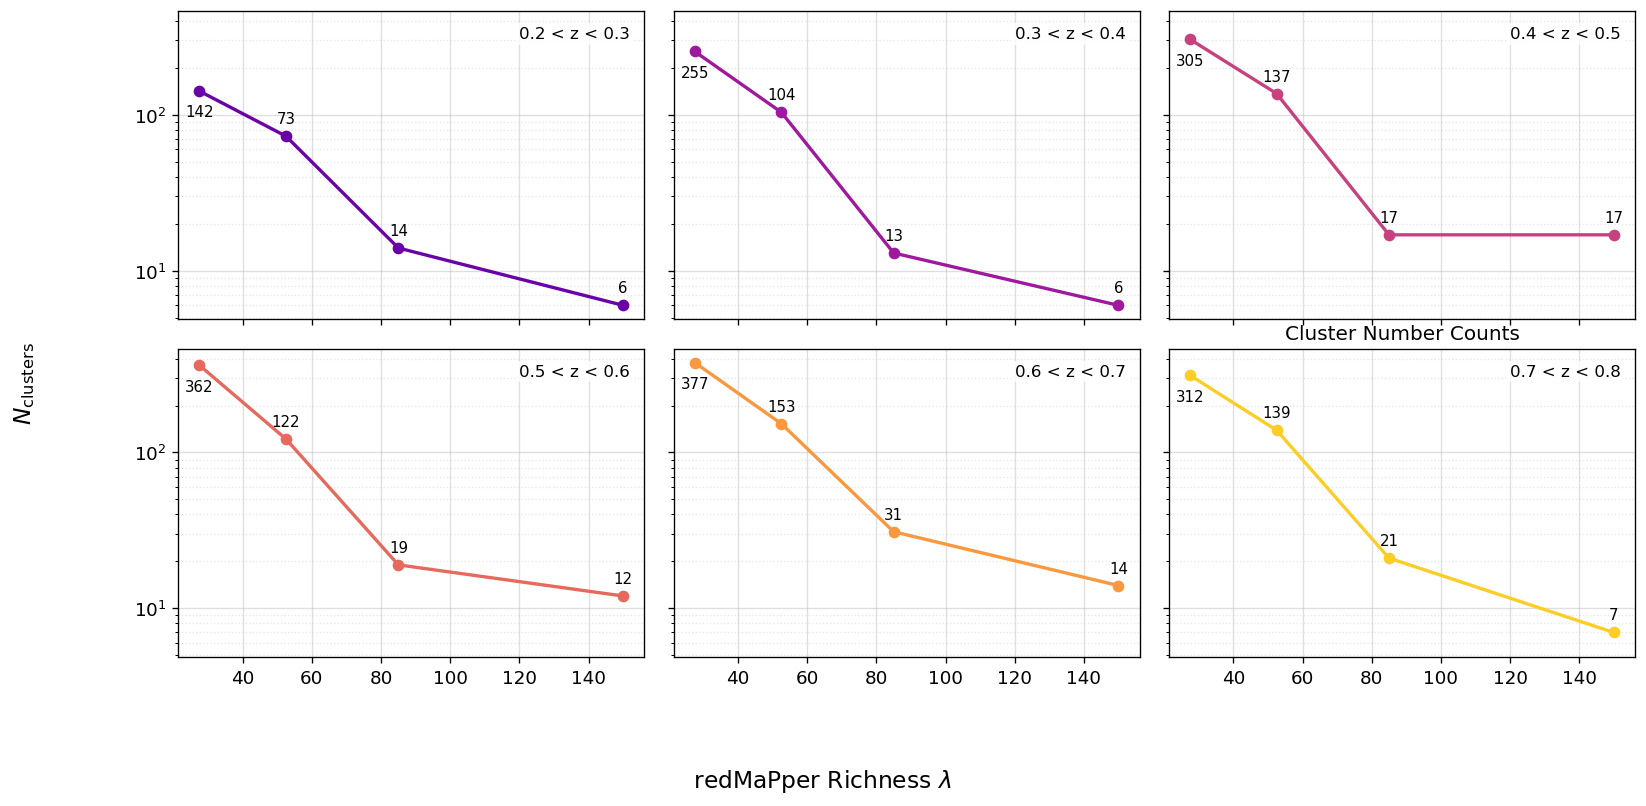

Total Clusters: 2658.0


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Compute richness bin centers ----------
rich_centers = 0.5 * (10**Rich_bins[:, 0] + 10**Rich_bins[:, 1])

# ---------- Use data-driven dimensions ----------
n_z = counts_data.shape[0]
n_r = counts_data.shape[1]

# Redshift labels (USE THESE, not Z_bins)
z_bin_label = ["0.2 < z < 0.3", "0.3 < z < 0.4", "0.4 < z < 0.5",
               "0.5 < z < 0.6", "0.6 < z < 0.7", "0.7 < z < 0.8"]

# ---------- Global style ----------
plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 13,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 120
})

# ---------- Layout ----------
ncols = 3
nrows = int(np.ceil(n_z / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 7), sharex=True, sharey=True)
axes = axes.flatten()

# ---------- Colors ----------
colors = plt.cm.plasma(np.linspace(0.2, 0.9, n_z))  # nicer than viridis for contrast

# ---------- Plot loop ----------
for i in range(n_z):
    ax = axes[i]

    y = counts_data[i, :]

    ax.plot(
        rich_centers,
        y,
        marker='o',
        linestyle='-',
        linewidth=2,
        markersize=6,
        color=colors[i]
    )

    # ---------- Annotate each point ----------
    ymax = np.max(y)
    
    for x, val in zip(rich_centers, y):
        if val > 0:
            # If close to top → place label BELOW
            if val > 0.7 * ymax:
                offset = (0, -8)
                va = 'top'
            else:
                offset = (0, 6)
                va = 'bottom'
    
            ax.annotate(
                f"{int(val)}",
                (x, val),
                textcoords="offset points",
                xytext=offset,
                ha='center',
                va=va,
                fontsize=9
            )

    # ---------- Log scale ----------
    ax.set_yscale("log")

    # ---------- Grid ----------
    ax.grid(True, which='major', linestyle='-', alpha=0.4)
    ax.grid(True, which='minor', linestyle=':', alpha=0.3)

    # ---------- Panel label ----------
    ax.text(
        0.97, 0.95,
        z_bin_label[i],
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2)
    )

# ---------- Hide unused panels ----------
for j in range(n_z, len(axes)):
    axes[j].axis('off')

# ---------- Shared labels ----------
fig.supxlabel(r" redMaPper Richness $\lambda$", fontsize=14)
fig.supylabel(r"$N_{\mathrm{clusters}}$", fontsize=14)

# ---------- Layout ----------
plt.tight_layout(rect=[0.05, 0.05, 1, 0.97])
plt.title("Cluster Number Counts")
# ---------- Save ----------

plt.show()

print(f"Total Clusters: {np.sum(counts_data.flatten())}")

## Computing Mean Halo Concentration

cat1_id,cat1_z,cat1_ra,cat1_dec,cat1_richness,cat1_richness_err,cat1_id_cg,cat1_ztrue_cg,cat1_p_cg_0,cat1_mt_self,cat1_mt_other,cat1_mt_multi_self,cat1_mt_multi_other,cat1_mt_frac_self,cat1_mt_frac_other,cat1_mt_cross,cat1_mt_frac,cat2_id,cat2_z,cat2_ra,cat2_dec,cat2_mass_fof,cat2_M200c,cat2_skysim_halo_id,cat2_mt_self,cat2_mt_other,cat2_mt_multi_self,cat2_mt_multi_other,cat2_mt_frac_other,cat2_mt_frac_self,cat2_mt_cross,cat2_mt_frac
bytes11,float32,float64,float64,float32,float32,int64,float32,float32,bytes13,bytes13,bytes150,bytes150,float64,float64,bytes13,float64,bytes21,float64,float64,float64,float64,float64,float64,bytes6,bytes6,bytes31,bytes31,float64,float64,bytes6,float64
10,0.5135129,52.520436430812914,-25.717996124671657,190.70665,3.7469666,1312945563,0.51072353,0.79138356,1162500021323,1162500021323,"1162500021323,922700021315,205900021323,417800021323,665600021315,1361100021315,711400021315,80500021323","80500021323,922700021315,205900021323,417800021323,665600021315,1361100021315,711400021315,1162500021323",0.4496726208984491,0.30094043887147337,1162500021323,0.4496726208984491,1162500021323,0.5107235191306336,52.520436430812914,-25.717996124671657,546154289100078.9,326491145207346.5,1156008787323.0,10,10,10,10,0.4496726208984491,0.30094043887147337,10,0.30094043887147337
18,0.5712697,56.920376528125075,-27.20434071042304,179.12813,3.6934361,2000524808,0.5740297,0.99996513,549500032315,549500032315,549500032315,549500032315,0.9421648861882373,0.35064935064935066,549500032315,0.9421648861882373,549500032315,0.5740296938561777,56.920376528125075,-27.20434071042304,1009535371108236.6,645749230889104.2,158908916315.0,18,18,18,18,0.9421648861882373,0.35064935064935066,18,0.35064935064935066
24,1.040338,56.99849698116052,-26.7172081871169,124.02715,2.4172914,2002535198,1.0347759,0.93527913,2554900032241,2554900032241,"2554900032241,1212700032259,3011300032241","2554900032241,1212700032259,3011300032241",0.9468829847683286,0.28444444444444444,2554900032241,0.9468829847683286,2554900032241,1.034775804769664,56.99849698116052,-26.7172081871169,381884526534309.9,383668275413453.56,3667408916241.0,24,24,24,24,0.9468829847683286,0.28444444444444444,24,0.28444444444444444
30,0.63518524,58.56362402841767,-27.429961828331713,167.33603,3.6777163,2000759779,0.6426174,0.9958548,1275900032300,1275900032300,"6600032300,1275900032300,23400032300","6600032300,1275900032300,23400032300",0.9812835255072209,0.2767857142857143,1275900032300,0.9812835255072209,1275900032300,0.6426174147729209,58.56362402841767,-27.429961828331713,388491914052507.06,216337687012597.2,1087308916300.0,30,30,30,30,0.9812835255072209,0.2767857142857143,30,0.2767857142857143
71,0.44230303,58.35519782866568,-26.867687128773035,111.9147,3.366554,2000289335,0.43919736,0.7297119,564000032338,564000032338,"161400032338,359200032338,731900032338,564000032338,778100032338,243000032347","161400032338,359200032338,731900032338,564000032338,778100032338,243000032347",0.5346957617359577,0.2518518518518518,564000032338,0.5346957617359577,564000032338,0.4385807111345399,58.34992458608299,-26.866270557202213,356926172895549.3,322972230485814.1,252508916338.0,71,71,71,71,0.5346957617359577,0.2518518518518518,71,0.2518518518518518
73,0.46697217,57.76575707007693,-28.119101936484828,104.439766,2.9570596,2000290819,0.4680865,0.99970347,459400032338,459400032338,"2200032331,459400032338,980800032331","2200032331,459400032338,980800032331",0.9046435837281485,0.2780612244897959,459400032338,0.9046435837281485,459400032338,0.4680865186324199,57.76575707007693,-28.119101936484828,358202422805633.8,278007164916462.0,175708916338.0,73,73,"73,4848","73,4848",0.9046435837281485,0.2780612244897959,73,0.2780612244897959
109,0.4413634,58.509466974185045,-26.989676182075844,103.49396,3.3524604,2000286447,0.44349608,0.99999905,156700032338,156700032338,"156700032338,433200032355","156700032338,433200032355",0.9589822433529834,0.28672985781990523,156700032338,0.9589822433529834,156700032338,0.

Median concentration = 3.800


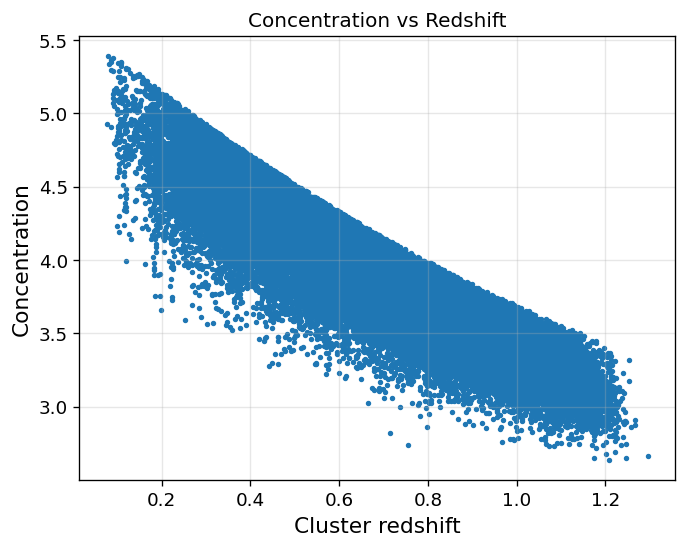

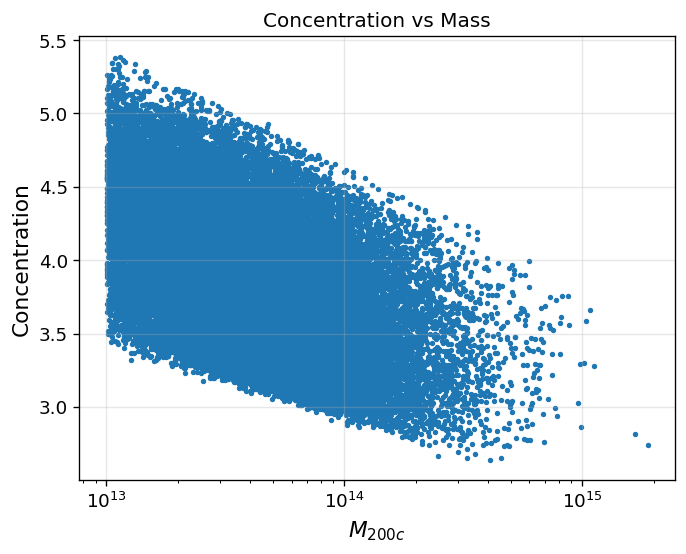

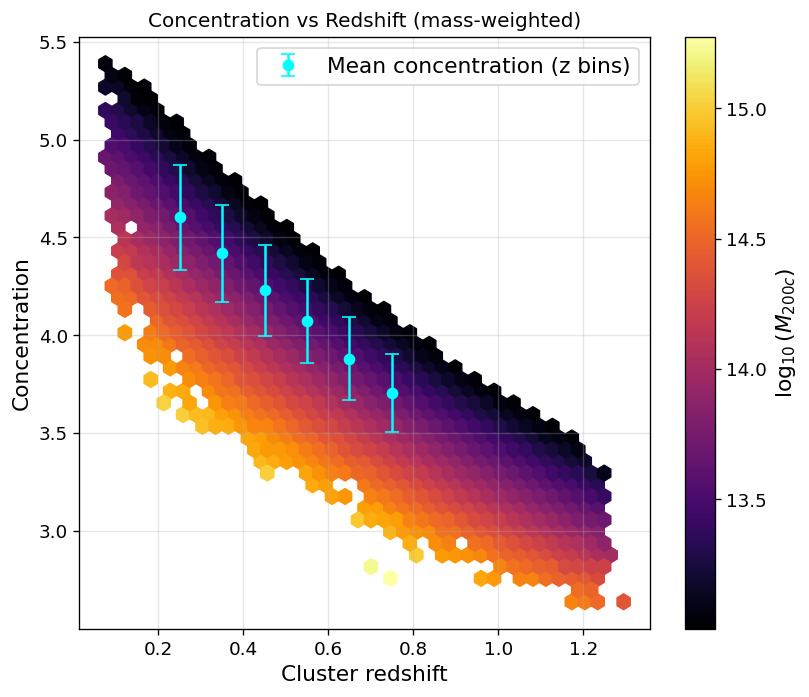

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
import pyccl as ccl
from IPython.display import display

# ─────────────────────────────────────────────────────────────
# Config
# ─────────────────────────────────────────────────────────────
PATH = "/sps/lsst/users/ebarroso/CLCosmo_Sim_database/data/"
FILE = "matched_pairs_Mfofcut.fits"
MASS_CUT = 1e12


# ─────────────────────────────────────────────────────────────
# Load data
# ─────────────────────────────────────────────────────────────
table = Table.read(PATH + FILE)
display(table)

# Apply mass cut
mask_mass = table["cat2_M200c"] > MASS_CUT
data = table[mask_mass]

# Extract arrays once (avoid repeated table access)
z = np.array(data["cat1_ztrue_cg"])
m = np.array(data["cat2_M200c"])
a = 1.0 / (1.0 + z)

# ─────────────────────────────────────────────────────────────
# Cosmology + concentration model
# ─────────────────────────────────────────────────────────────
cosmo = ccl.Cosmology(
    Omega_c=0.1109 / 0.71**2,
    Omega_b=0.02258 / 0.71**2,
    h=0.71,
    n_s=0.963,
    sigma8=0.8,
    w0=-1.0,
    wa=0.0,
    transfer_function="boltzmann_camb",
)

conc_model = ccl.halos.concentration.ConcentrationBhattacharya13(mass_def="200c")

# Vectorized concentration computation
conc = np.array([
    conc_model(cosmo, mi, float(ai))
    for mi, ai in zip(m, a)
])

# ─────────────────────────────────────────────────────────────
# Basic diagnostics
# ─────────────────────────────────────────────────────────────
print(f"Median concentration = {np.median(conc):.3f}")
cluster_concentration = np.median(conc)
# ─────────────────────────────────────────────────────────────
# Simple scatter plots
# ─────────────────────────────────────────────────────────────
plt.figure()
plt.scatter(z, conc, s=5)
plt.xlabel("Cluster redshift")
plt.ylabel("Concentration")
plt.title("Concentration vs Redshift")
plt.grid(alpha=0.3)
plt.show()

plt.figure()
plt.scatter(m, conc, s=5)
plt.xlabel(r"$M_{200c}$")
plt.ylabel("Concentration")
plt.title("Concentration vs Mass")
plt.xscale("log")
plt.grid(alpha=0.3)
plt.show()

# ─────────────────────────────────────────────────────────────
# Hexbin (mass-colored)
# ─────────────────────────────────────────────────────────────
logm = np.log10(m)

plt.figure(figsize=(7, 6))
hb = plt.hexbin(
    z,
    conc,
    C=logm,
    reduce_C_function=np.mean,
    gridsize=40,
    cmap="inferno",
)

cbar = plt.colorbar(hb)
cbar.set_label(r"$\log_{10}(M_{200c})$")

# ─────────────────────────────────────────────────────────────
# Redshift bin statistics
# ─────────────────────────────────────────────────────────────
z_centers = []
mean_conc = []
std_conc = []

for zmin, zmax in Z_bins:
    mask = (z >= zmin) & (z < zmax)

    if np.any(mask):
        c_bin = conc[mask]
        z_centers.append(0.5 * (zmin + zmax))
        mean_conc.append(np.mean(c_bin))
        std_conc.append(np.std(c_bin))

z_centers = np.array(z_centers)
mean_conc = np.array(mean_conc)
std_conc = np.array(std_conc)

# Overlay binned stats
plt.errorbar(
    z_centers,
    mean_conc,
    yerr=std_conc,
    fmt="o",
    color="cyan",
    capsize=4,
    label="Mean concentration (z bins)",
)

# ─────────────────────────────────────────────────────────────
# Final plot formatting
# ─────────────────────────────────────────────────────────────
plt.xlabel("Cluster redshift")
plt.ylabel("Concentration")
plt.title("Concentration vs Redshift (mass-weighted)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Prediction fiducial

In [5]:
from crow import ClusterShearProfile
from crow import ClusterAbundance
from crow.recipes.binned_exact import ExactBinnedClusterRecipe
from crow.recipes.binned_grid import GridBinnedClusterRecipe
from crow import completeness_models, mass_proxy, purity_models, kernel
from crow.properties import ClusterProperty


mass_richness_unb = mass_proxy.MurataUnbinned(pivot_log_mass=14.3, pivot_redshift=0.5)
mass_richness_unb.parameters["mu0"] = 3.3442
mass_richness_unb.parameters["mu1"] = 0.9577
mass_richness_unb.parameters["mu2"] = -0.0190
mass_richness_unb.parameters["sigma0"] = 0.5625
mass_richness_unb.parameters["sigma1"] =0.0458
mass_richness_unb.parameters["sigma2"] = -0.0458



hmf = ccl.halos.MassFuncDespali16(mass_def="200c")
cosmo = ccl.Cosmology(
    Omega_c=0.1109 / 0.71**2,
    Omega_b=0.02258 / 0.71**2,
    h=0.71,
    n_s=0.963,
    sigma8=0.8,
    w0=-1.0,
    wa=0.0,
    transfer_function="boltzmann_camb"
)

mass_grid_size = 200
redshift_grid_size = 40
proxy_grid_size = 40
sky_area =  440.78987
mass_interval = (12.0, 15.5)


cl_abundandce = ClusterAbundance(cosmo, hmf)
completeness_aguena = completeness_models.CompletenessAguena16()
cl_delta_sigma = ClusterShearProfile(
    cosmo, hmf, is_delta_sigma=True, cluster_concentration=cluster_concentration
)
redshift_distribution = kernel.SpectroscopicRedshift()


In [6]:
recipe_grid_abundance = GridBinnedClusterRecipe(
    mass_interval=mass_interval,
    cluster_theory=cl_abundandce,
    redshift_distribution=redshift_distribution,
    mass_distribution=mass_richness_unb,
    proxy_grid_size=proxy_grid_size,
    redshift_grid_size=redshift_grid_size,
    mass_grid_size=mass_grid_size,
    purity=None,
    completeness=completeness_aguena
)

recipe_grid_shear = GridBinnedClusterRecipe(
    mass_interval=mass_interval,
    cluster_theory=cl_delta_sigma,
    redshift_distribution=redshift_distribution,
    mass_distribution=mass_richness_unb,
    proxy_grid_size=proxy_grid_size,
    redshift_grid_size=redshift_grid_size,
    mass_grid_size=mass_grid_size,
    purity=None,
    completeness=completeness_aguena
)

recipe_grid_abundance.setup()
recipe_grid_shear.setup()

grid_counts_vals  = np.zeros((len(Z_bins), len(Rich_bins)))
grid_shear_vals  = np.zeros((len(Z_bins), len(Rich_bins), len(Radius_bins)))
grid_shear_error  = np.zeros((len(Z_bins), len(Rich_bins), len(Radius_bins)))
for i, zb in enumerate(Z_bins):
    for j, pb in enumerate(Rich_bins):
        print(f"Redshift x Log10 Richness bins: {zb, pb}")
        val_counts = recipe_grid_abundance.evaluate_theory_prediction_counts(np.array(zb), np.array(pb), sky_area)
        grid_counts_vals[i,j] = val_counts
        shear_vals = recipe_grid_shear.evaluate_theory_prediction_lensing_profile(np.array(zb), np.array(pb), np.array(Radius_bins), sky_area, ClusterProperty.DELTASIGMA) / val_counts
        grid_shear_vals[i,j, :] = shear_vals
        grid_shear_error[i, j, :] = abs(1.0 - shear_vals / shear_data[i, j, :])

rel_error_matrix = np.abs(1 - grid_counts_vals / counts_data)

n_i, n_j = rel_error_matrix.shape


print(f"Theoretical Counts: {grid_counts_vals}")

Redshift x Log10 Richness bins: (array([0.2, 0.3]), array([1.30103   , 1.54406804]))
Redshift x Log10 Richness bins: (array([0.2, 0.3]), array([1.54406804, 1.84509804]))
Redshift x Log10 Richness bins: (array([0.2, 0.3]), array([1.84509804, 2.        ]))
Redshift x Log10 Richness bins: (array([0.2, 0.3]), array([2.     , 2.30103]))
Redshift x Log10 Richness bins: (array([0.3, 0.4]), array([1.30103   , 1.54406804]))
Redshift x Log10 Richness bins: (array([0.3, 0.4]), array([1.54406804, 1.84509804]))
Redshift x Log10 Richness bins: (array([0.3, 0.4]), array([1.84509804, 2.        ]))
Redshift x Log10 Richness bins: (array([0.3, 0.4]), array([2.     , 2.30103]))
Redshift x Log10 Richness bins: (array([0.4, 0.5]), array([1.30103   , 1.54406804]))
Redshift x Log10 Richness bins: (array([0.4, 0.5]), array([1.54406804, 1.84509804]))
Redshift x Log10 Richness bins: (array([0.4, 0.5]), array([1.84509804, 2.        ]))
Redshift x Log10 Richness bins: (array([0.4, 0.5]), array([2.     , 2.30103])

## Best Fit Cosmo

In [7]:
### from crow import ClusterShearProfile
from crow import ClusterAbundance
from crow.recipes.binned_exact import ExactBinnedClusterRecipe
from crow.recipes.binned_grid import GridBinnedClusterRecipe
from crow import completeness_models, mass_proxy, purity_models, kernel
from crow.properties import ClusterProperty


mass_richness_unb_fit = mass_proxy.MurataUnbinned(pivot_log_mass=14.3, pivot_redshift=0.5)
mass_richness_unb_fit.parameters["mu0"] = 3.4334793
mass_richness_unb_fit.parameters["mu1"] =0.92793217 
mass_richness_unb_fit.parameters["mu2"] = -0.29343203
mass_richness_unb_fit.parameters["sigma0"] = 0.49620235 
mass_richness_unb_fit.parameters["sigma1"] = 0.065603676
mass_richness_unb_fit.parameters["sigma2"] = 0.51616388 



hmf = ccl.halos.MassFuncDespali16(mass_def="200c")
cosmo_fit = ccl.Cosmology(
    Omega_c=0.22370613,
    Omega_b=0.02258 / 0.71**2,
    h=0.71,
    n_s=0.963,
    sigma8=0.78845163,
    w0=-1.0,
    wa=0.0,
    transfer_function="boltzmann_camb"
)

mass_grid_size = 200
redshift_grid_size = 40
proxy_grid_size = 40
sky_area =  440.78987
mass_interval = (12.0, 15.5)


cl_abundandce = ClusterAbundance(cosmo_fit, hmf)
completeness_aguena = completeness_models.CompletenessAguena16()
cl_delta_sigma = ClusterShearProfile(
    cosmo_fit, hmf, is_delta_sigma=True, cluster_concentration=cluster_concentration
)
redshift_distribution = kernel.SpectroscopicRedshift()


In [8]:
recipe_grid_abundance = GridBinnedClusterRecipe(
    mass_interval=mass_interval,
    cluster_theory=cl_abundandce,
    redshift_distribution=redshift_distribution,
    mass_distribution=mass_richness_unb_fit,
    proxy_grid_size=proxy_grid_size,
    redshift_grid_size=redshift_grid_size,
    mass_grid_size=mass_grid_size,
    purity=None,
    completeness=completeness_aguena
)

recipe_grid_shear = GridBinnedClusterRecipe(
    mass_interval=mass_interval,
    cluster_theory=cl_delta_sigma,
    redshift_distribution=redshift_distribution,
    mass_distribution=mass_richness_unb_fit,
    proxy_grid_size=proxy_grid_size,
    redshift_grid_size=redshift_grid_size,
    mass_grid_size=mass_grid_size,
    purity=None,
    completeness=completeness_aguena
)

recipe_grid_abundance.setup()
recipe_grid_shear.setup()

grid_counts_vals_fit  = np.zeros((len(Z_bins), len(Rich_bins)))
grid_shear_vals_fit  = np.zeros((len(Z_bins), len(Rich_bins), len(Radius_bins)))
grid_shear_error_fit  = np.zeros((len(Z_bins), len(Rich_bins), len(Radius_bins)))
for i, zb in enumerate(Z_bins):
    for j, pb in enumerate(Rich_bins):
        print(f"Redshift x Log10 Richness bins: {zb, pb}")
        val_counts = recipe_grid_abundance.evaluate_theory_prediction_counts(np.array(zb), np.array(pb), sky_area)
        grid_counts_vals_fit[i,j] = val_counts
        shear_vals = recipe_grid_shear.evaluate_theory_prediction_lensing_profile(np.array(zb), np.array(pb), np.array(Radius_bins), sky_area, ClusterProperty.DELTASIGMA) / val_counts
        grid_shear_vals_fit[i,j, :] = shear_vals
        grid_shear_error_fit[i, j, :] = abs(1.0 - shear_vals / shear_data[i, j, :])

rel_error_matrix_fit = np.abs(1 - grid_counts_vals_fit / counts_data)

n_i, n_j = rel_error_matrix_fit.shape


print(f"Theoretical Counts: {grid_counts_vals_fit}")

Redshift x Log10 Richness bins: (array([0.2, 0.3]), array([1.30103   , 1.54406804]))
Redshift x Log10 Richness bins: (array([0.2, 0.3]), array([1.54406804, 1.84509804]))
Redshift x Log10 Richness bins: (array([0.2, 0.3]), array([1.84509804, 2.        ]))
Redshift x Log10 Richness bins: (array([0.2, 0.3]), array([2.     , 2.30103]))
Redshift x Log10 Richness bins: (array([0.3, 0.4]), array([1.30103   , 1.54406804]))
Redshift x Log10 Richness bins: (array([0.3, 0.4]), array([1.54406804, 1.84509804]))
Redshift x Log10 Richness bins: (array([0.3, 0.4]), array([1.84509804, 2.        ]))
Redshift x Log10 Richness bins: (array([0.3, 0.4]), array([2.     , 2.30103]))
Redshift x Log10 Richness bins: (array([0.4, 0.5]), array([1.30103   , 1.54406804]))
Redshift x Log10 Richness bins: (array([0.4, 0.5]), array([1.54406804, 1.84509804]))
Redshift x Log10 Richness bins: (array([0.4, 0.5]), array([1.84509804, 2.        ]))
Redshift x Log10 Richness bins: (array([0.4, 0.5]), array([2.     , 2.30103])

## Final plots

In [9]:
# ------------------------------------------------------------
# Errors from SACC covariance
# ------------------------------------------------------------
cov = sacc_file.covariance.covmat

counts_err = np.zeros_like(counts_data)
shear_err = np.zeros_like(shear_data)

for i in range(n_z):
    for j in range(n_r):

        trac_counts = (
            "cosmodc2_redmapper",
            f"bin_rich_{j}",
            f"bin_z_{i}",
        )

        ind = sacc_file.indices(
            sacc.data_types.standard_types.cluster_counts,
            tracers=trac_counts,
        )

        counts_err[i, j] = np.sqrt(cov[ind[0], ind[0]])

        for k in range(n_rad):

            trac_shear = (
                "cosmodc2_redmapper",
                f"bin_rich_{j}",
                f"bin_z_{i}",
                f"radius_{k}",
            )

            ind = sacc_file.indices(
                sacc.data_types.standard_types.cluster_delta_sigma,
                tracers=trac_shear,
            )

            shear_err[i, j, k] = np.sqrt(cov[ind[0], ind[0]])

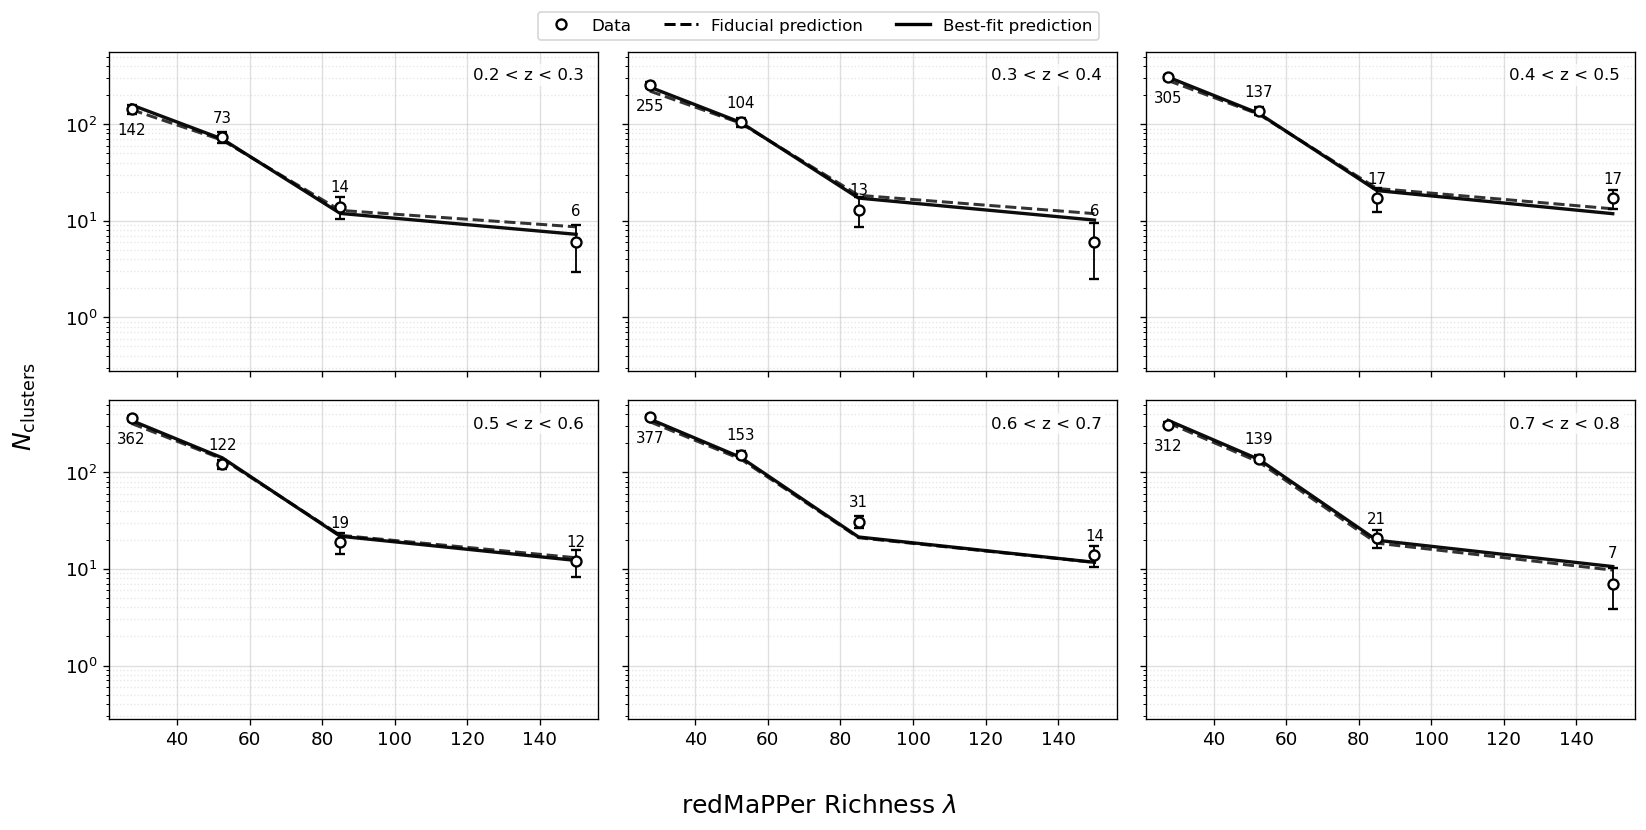

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------- Compute richness bin centers ----------
rich_centers = 0.5 * (10**Rich_bins[:, 0] + 10**Rich_bins[:, 1])

# ---------- Use data-driven dimensions ----------
n_z = counts_data.shape[0]
n_r = counts_data.shape[1]

z_bin_label = [
    "0.2 < z < 0.3",
    "0.3 < z < 0.4",
    "0.4 < z < 0.5",
    "0.5 < z < 0.6",
    "0.6 < z < 0.7",
    "0.7 < z < 0.8",
]

# ---------- Global style ----------
plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 13,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 120,
})

# ---------- Layout ----------
ncols = 3
nrows = int(np.ceil(n_z / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 7), sharex=True, sharey=True)
axes = axes.flatten()


# ---------- Plot loop ----------
for i in range(n_z):
    ax = axes[i]
    color = "black"
    y = counts_data[i, :]

    # Data: open circles only
    ax.errorbar(
        rich_centers,
        counts_data[i, :],
        yerr=counts_err[i, :],
        fmt="o",
        color=color,
        markerfacecolor="white",
        markeredgecolor=color,
        markeredgewidth=1.4,
        markersize=6,
        capsize=3,
        elinewidth=1.1,
        linestyle="none",
        zorder=4,
    )

    # Fiducial prediction: dashed
    ax.plot(
        rich_centers,
        grid_counts_vals[i, :],
        linestyle="--",
        linewidth=1.8,
        color=color,
        alpha=0.8,
        zorder=2,
    )

    # Best-fit prediction: solid
    ax.plot(
        rich_centers,
        grid_counts_vals_fit[i, :],
        linestyle="-",
        linewidth=2.0,
        color=color,
        alpha=0.95,
        zorder=3,
    )

    # ---------- Annotate data points ----------
    ymax = np.max(y)

    special_z_bins = {0, 1, 5}
    
    # Last richness bin
    last_richness_bin = len(rich_centers) - 1
    
    for k, (x, val) in enumerate(zip(rich_centers, y)):
        if val > 0:
    
            # Special case: only last richness point in redshift bins 1, 2, and 6
            if (i in special_z_bins) and (k == last_richness_bin):
                offset = (0, 14)   # move upward
                va = "bottom"
    
            # Default behavior
            elif val > 0.7 * ymax:
                offset = (0, -8)
                va = "top"
            else:
                offset = (0, 7)
                va = "bottom"
    
            ax.annotate(
                f"{int(val)}",
                (x, val),
                textcoords="offset points",
                xytext=offset,
                ha="center",
                va=va,
                fontsize=9,
            )

    ax.set_yscale("log")

    ax.grid(True, which="major", linestyle="-", alpha=0.4)
    ax.grid(True, which="minor", linestyle=":", alpha=0.3)

    ax.text(
        0.97,
        0.95,
        z_bin_label[i],
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2),
    )

# ---------- Hide unused panels ----------
for j in range(n_z, len(axes)):
    axes[j].axis("off")

# ---------- Shared labels ----------
fig.supxlabel(r"redMaPPer Richness $\lambda$", fontsize=15)
fig.supylabel(r"$N_{\mathrm{clusters}}$", fontsize=15)

# ---------- Legend ----------
style_handles = [
    Line2D(
        [0], [0],
        color="black",
        marker="o",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.4,
        linestyle="none",
        markersize=6,
        label="Data",
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle="--",
        lw=1.8,
        label="Fiducial prediction",
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle="-",
        lw=2.0,
        label="Best-fit prediction",
    ),
]

fig.legend(
    handles=style_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=3,
    fontsize=10,
    frameon=True,
)

plt.tight_layout(rect=[0.008, 0.008, 1, 0.95])
plt.savefig("./figures/counts_vs_richness_with_predictions.pdf", dpi=300)
plt.show()

In [11]:
# chi^2 / N for data vs fiducial prediction
data = np.asarray(counts_data, dtype=float)
model = np.asarray(grid_counts_vals, dtype=float)
err = np.asarray(counts_err, dtype=float)

mask = np.isfinite(data) & np.isfinite(model) & np.isfinite(err) & (err > 0)

chi2 = np.sum(((data[mask] - model[mask]) / err[mask])**2)
N = np.sum(mask)

print(f"chi2 = {chi2:.3f}")
print(f"N = {N}")
print(f"chi2 / N = {chi2 / N:.3f}")
print(np.mean(abs(model/data - 1.0)))

chi2 = 33.660
N = 24
chi2 / N = 1.403
0.19205221702593347


In [ ]:
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

rich_colors = plt.cm.magma(np.linspace(0.25, 0.85, n_r))

ncols = 3
nrows = int(np.ceil(n_z / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(15, 8),
    sharex=True,
    sharey=True,
)

axes = axes.flatten()

for i in range(n_z):
    ax = axes[i]

    for j in range(n_r):
        color = rich_colors[j]

        # Data: points only + error bars
        ax.errorbar(
            Radius_bins,
            shear_data[i, j, :],
            yerr=shear_err[i, j, :],
            fmt="o",
            color=color,
            markerfacecolor="white",
            markeredgecolor=color,
            markeredgewidth=1.2,
            markersize=5,
            elinewidth=0.9,
            capsize=2,
            linestyle="none",
            alpha=0.95,
            zorder=5,
        )

        # Fiducial prediction: dashed line
        ax.plot(
            Radius_bins,
            grid_shear_vals[i, j, :],
            linestyle="--",
            color=color,
            linewidth=1.7,
            alpha=0.75,
            zorder=3,
        )

        # Best-fit prediction: solid line
        ax.plot(
            Radius_bins,
            grid_shear_vals_fit[i, j, :],
            linestyle="-",
            color=color,
            linewidth=2.0,
            alpha=0.95,
            zorder=4,
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(left=1.1)
    ax.set_ylim(bottom=2e12)

    ax.grid(True, which="major", linestyle="--", alpha=0.35)
    ax.grid(True, which="minor", linestyle=":", alpha=0.2)

    ax.text(
        0.97,
        0.95,
        z_bin_label[i],
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none", pad=2),
    )

    ax.xaxis.set_major_locator(mticker.FixedLocator([1, 2, 3, 4]))
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:g}"))

for j in range(n_z, len(axes)):
    axes[j].axis("off")

fig.supxlabel(r"$R\ [\mathrm{Mpc}]$", fontsize=14)
fig.supylabel(r"$\Delta\Sigma\ [M_\odot\,\mathrm{Mpc}^{-2}]$", fontsize=14)

style_handles = [
    Line2D(
        [0], [0],
        color="black",
        marker="o",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.2,
        linestyle="none",
        markersize=5,
        label="Data",
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle="--",
        lw=1.7,
        label="Fiducial prediction",
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle="-",
        lw=2.0,
        label="Best-fit prediction",
    ),
]

rich_handles = [
    Line2D(
        [0], [0],
        color=rich_colors[j],
        lw=2,
        label=rf"$\lambda$ bin {rich_bin_label[j]}",
    )
    for j in range(n_r)
]

fig.legend(
    handles=style_handles + rich_handles,
    loc="lower center",
    bbox_to_anchor=(0.54, 0.92),
    ncol=3 + n_r,
    fontsize=11,
    frameon=True,
    framealpha=0.95,
    edgecolor="0.8",
)

plt.tight_layout(rect=[0.0008, 0.001, 1, 0.93])
plt.savefig(
    "./figures/shear_profiles_with_predictions.pdf",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.08,
)
plt.show()

In [ ]:
# chi^2 / N for shear data vs fiducial prediction
data = np.asarray(shear_data, dtype=float)
model = np.asarray(grid_shear_vals, dtype=float)
err = np.asarray(shear_err, dtype=float)

mask = np.isfinite(data) & np.isfinite(model) & np.isfinite(err) & (err > 0)

chi2 = np.sum(((data[mask] - model[mask]) / err[mask])**2)
N = np.sum(mask)

print(f"chi2 = {chi2:.3f}")
print(f"N = {N}")
print(f"chi2 / N = {chi2 / N:.3f}")